# Agent Traces → Supervised Fine-Tuning

Distill a strong **teacher** model (`gpt-5.4` with `reasoning_effort="high"`) into a smaller **student** (`gpt-4.1-nano`) by:

1. measuring the **student baseline** on the canonical 30-scenario eval harness ([eval/scenarios_train.json](eval/scenarios_train.json));
2. measuring the **teacher reference baseline** on the same harness — the distillation ceiling;
3. driving the deployed Hosted Agent ([retail-agent-langgraph](src/retail-agent-langgraph/README.md)) under a customer simulator so every reasoning step + tool call is captured as OTel spans in App Insights;
4. having the `azure-ai-projects` SDK harvest those traces into an SFT-ready JSONL via `project_client.beta.datasets.create_generation_job(...)`.

The retail agent ships with the **same 6 tools** as the local Zava lab ([samples/datasets/agents/Zava-Ignite-RL-Lab](../../../datasets/agents/Zava-Ignite-RL-Lab)) and the **same scoring rubric** ([eval/evaluate.py](eval/evaluate.py)) — so baselines from the two demos are directly comparable.

## Pipeline

```
                                   +----------------------------+
                                   |  Baseline eval (student)   |
                                   |  gpt-4.1-nano -> rubric    |
                                   +----------------------------+
                                                  |
+-------------------+    +-----------------------+    +-----------------+    +----------------------------+    +-------------+
| Customer LLM      |--->| Hosted Agent          |--->| App Insights    |--->| project_client.beta.       |--->| SFT JSONL   |
| (gpt-5.4-mini)    |<---| retail-agent-langgraph|    | (gen_ai.* spans)|    | datasets.create_           |    | (train+val) |
| chat.completions  |    | Responses API session |    |                 |    | generation_job(traces)     |    |             |
+-------------------+    +-----------------------+    +-----------------+    +----------------------------+    +-------------+
                              ^ TEACHER (gpt-5.4 high) drives the trace
```

## Sections

1. **Setup** — connect to the Foundry project + grab the App Insights connection string.
2. **Student baseline** — score `gpt-4.1-nano` on the 30 canonical scenarios *before* fine-tuning.
3. **Teacher reference baseline** — score `gpt-5.4` (high reasoning) on the same scenarios.
4. **Pin agent endpoint + customer simulator** — wire the deployed Hosted Agent + a `gpt-5.4-mini` customer persona.
5. **Generate teacher traffic** — drive simulated conversations with the teacher so its reasoning + tool sequences become the distillation source.
6. **Submit a `traces` data-generation job** — `TracesDataGenerationJobSource` filters on `gen_ai.agent.name` and the service stitches each trace into an SFT example.
7. **Inspect + patch the SFT JSONL** — preview the produced corpus and shape it for the OpenAI fine-tuning API.
8. **Closing the loop** — fine-tune the student model.
9. **Post-SFT eval** — multi-pass cumulative pass@k on the training-distribution AND held-out scenario sets, with an uplift bar chart.
10. **Headline + caveats** — what we can and cannot claim from the result.

> ⚠️ *Trace-based data generation is in **public preview** in `azure-ai-projects` (`project_client.beta.datasets`). The deployed agent already auto-emits OTel GenAI semantic-convention spans via `enable_auto_tracing(...)` in [src/retail-agent-langgraph/main.py](src/retail-agent-langgraph/main.py), so no hand-rolled instrumentation is needed in this notebook.*

## Prerequisites

1. The `retail-agent-langgraph` agent has been deployed to your Foundry project — follow [src/retail-agent-langgraph/README.md](src/retail-agent-langgraph/README.md) (`azd ai agent init` → `azd deploy`). The agent loads its policy + 6 retail tools (same surface as the Zava lab) on startup.
2. The Foundry project has **Application Insights** attached.
3. Both `gpt-4.1-nano` (student) and `gpt-5.4` (teacher) are deployed under the project, and the deployment names match `STUDENT_MODEL` / `TEACHER_MODEL` below. `gpt-5.4-mini` is the customer simulator.
4. A `.env` file next to this notebook with at minimum:

   ```
   FOUNDRY_PROJECT_ENDPOINT=https://<resource>.services.ai.azure.com/api/projects/<project>
   FOUNDRY_HOSTED_AGENT_NAME=retail-agent-langgraph
   STUDENT_MODEL=gpt-4.1-nano
   TEACHER_MODEL=gpt-5.4
   CUSTOMER_MODEL=gpt-5.4-mini
   AZURE_OPENAI_ENDPOINT=https://<resource>.services.ai.azure.com
   ```

In [1]:
%pip install -q ./azure_ai_projects-2.2.0-py3-none-any.whl python-dotenv langchain-openai langchain-azure-ai langgraph azure-monitor-opentelemetry

Note: you may need to restart the kernel to use updated packages.


## 1. Setup

In [19]:
import json
import os
import sys
import time
import uuid
from datetime import datetime, timedelta, timezone
from pathlib import Path

from dotenv import load_dotenv
from azure.identity import DefaultAzureCredential
from azure.ai.projects import AIProjectClient

load_dotenv()

NB_DIR = Path.cwd()
AGENT_DIR = NB_DIR / "src" / "retail-agent-langgraph"
EVAL_DIR = NB_DIR / "eval"
RESULTS_DIR = NB_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# Make `main` (the deployed agent's module) and `evaluate` (the eval harness)
# importable from this notebook regardless of where the kernel was started.
for p in (str(AGENT_DIR), str(EVAL_DIR)):
    if p not in sys.path:
        sys.path.insert(0, p)

ENDPOINT = os.environ["FOUNDRY_PROJECT_ENDPOINT"]
AGENT_NAME = "retail-agent-langgraph"
STUDENT_MODEL = os.environ.get("STUDENT_MODEL", "gpt-4.1-nano")
TEACHER_MODEL = os.environ.get("TEACHER_MODEL", "gpt-5.4")
CUSTOMER_MODEL = os.environ.get("CUSTOMER_MODEL", "gpt-5.4-mini")

credential = DefaultAzureCredential()
project_client = AIProjectClient(endpoint=ENDPOINT, credential=credential, allow_preview=True)

# Sanity-check the data-generation surface we'll use later.
for m in (
    "list_generation_jobs",
    "create_generation_job",
    "get_generation_job",
    "cancel_generation_job",
    "delete_generation_job",
):
    assert hasattr(project_client.beta.datasets, m), f"Missing method: {m}"
print("project_client.beta.datasets generation-job methods OK")

APPINSIGHTS_CONN_STRING = project_client.telemetry.get_application_insights_connection_string()
assert APPINSIGHTS_CONN_STRING, (
    "This Foundry project has no Application Insights resource attached. "
    "Attach one in the portal (Project settings -> Telemetry) before running this notebook."
)
print(f"App Insights connection string acquired (length: {len(APPINSIGHTS_CONN_STRING)})")
print(f"Hosted agent:    {AGENT_NAME}")
print(f"STUDENT (baseline + SFT target): {STUDENT_MODEL}")
print(f"TEACHER (high reasoning):        {TEACHER_MODEL}")
print(f"CUSTOMER simulator:              {CUSTOMER_MODEL}")

# Build `customer_client` here (not in §4) so the multi-turn baselines in §2/§3
# can run independently of the deployed-agent setup. Both the in-process eval
# baselines and the trace-driving simulator in §5/§6 share this same client. We
# prefer a *direct* OpenAI client (via OPENAI_BASE_URL + AZURE_OPENAI_API_KEY in
# .env) when set — that lets you pick CUSTOMER_MODEL deployments that aren't
# published in the Foundry project (e.g. gpt-5.4-mini). Falls back to the
# project-scoped client otherwise. The 180s timeout is bumped from the OpenAI
# client's 60s default so reasoning customer models (gpt-5.x, o*) don't hit
# APITimeoutError on cold first-turn responses; override via
# CUSTOMER_HTTP_TIMEOUT_SEC.
_customer_base_url = os.environ.get("OPENAI_BASE_URL")
_customer_api_key = os.environ.get("AZURE_OPENAI_API_KEY")
_customer_timeout = float(os.environ.get("CUSTOMER_HTTP_TIMEOUT_SEC", "180"))
if _customer_base_url and _customer_api_key:
    from openai import OpenAI
    customer_client = OpenAI(
        base_url=_customer_base_url,
        api_key=_customer_api_key,
        timeout=_customer_timeout,
        max_retries=2,
    )
    print(f"customer_client -> direct OpenAI ({_customer_base_url}), timeout={_customer_timeout}s")
else:
    customer_client = project_client.get_openai_client()
    print("customer_client -> project-scoped (CUSTOMER_MODEL must exist in the Foundry project)")


project_client.beta.datasets generation-job methods OK
App Insights connection string acquired (length: 238)
Hosted agent:    retail-agent-langgraph
STUDENT (baseline + SFT target): gpt-4.1-nano
TEACHER (high reasoning):        gpt-5.4
CUSTOMER simulator:              gpt-5.4-mini
customer_client -> direct OpenAI (https://williamliang-sweden-resource.services.ai.azure.com/api/projects/williamliang-sweden/openai/v1/), timeout=180.0s


## 2. Student baseline — score `gpt-4.1-nano` *before* distillation

We score the student on the canonical 30-scenario harness in [eval/scenarios_train.json](eval/scenarios_train.json) using the rubric from [eval/evaluate.py](eval/evaluate.py):

| Dimension              | Weight |
|------------------------|--------|
| Decision Correctness   | 40%    |
| Tool Usage             | 25%    |
| Financial Accuracy     | 25%    |
| Communication Quality  | 10%    |

The harness covers six policy families that exercise the deployed agent's tool surface end-to-end:

| Family | Example T-IDs |
|--------|---------------|
| Within-window refunds (single + multi-item) | T01, T03, T05, T17, T28 |
| Pure denial (sale-final / expired window / opened personal-care) | T07, T08, T09, T29 |
| Status-mismatch → cancellation redirect | T04, T20, T26, T30 |
| Late-delivery extension precedence | T11, T14, T25, T28 |
| Multi-item denial mix (one refund, one deny) | T10, T11, T24, T27 |
| OOS exchange / mid-conversation pivot / cross-order | T12, T13, T19, T24 |

The eval runs as a **multi-turn** customer↔agent conversation — same shape as the SFT corpus generated in §6 (and how the deployed Hosted Agent behaves in production). Each scenario seeds a `CUSTOMER_MODEL` simulator that opens vague and reveals details on demand; the agent has to drive the policy flow itself across multiple turns. That format match is what makes this baseline apples-to-apples comparable to the post-FT eval — a single-turn eval would mismatch the SFT format and under-measure the FT model.

The agent runs **in-process** via `zava_agent.run_agent` against the model deployment under test — no traces are emitted to App Insights here, so this baseline doesn't pollute the SFT corpus generated downstream.

In [20]:
import importlib
import evaluate as eval_module     # eval/evaluate.py

# Make the Zava lab's local agent importable for the in-process baselines.
# We use Zava's `run_agent` (raw OpenAI chat-completions tool-calling loop)
# because it natively understands OPENAI_BASE_URL + AZURE_OPENAI_API_KEY,
# avoids LangGraph's AAD requirement, and exercises the *same 6 retail tools*
# the deployed Hosted Agent uses (the retail tools were ported from the Zava
# lab — same db.json contents). That keeps baseline scores apples-to-apples.
ZAVA_LAB = (NB_DIR / "../../../datasets/agents/Zava-Ignite-RL-Lab").resolve()
if not (ZAVA_LAB / "src" / "zava_agent.py").exists():
    raise RuntimeError(f"Zava lab not found at {ZAVA_LAB}")
if str(ZAVA_LAB) not in sys.path:
    sys.path.insert(0, str(ZAVA_LAB))

import src.zava_agent as zava_agent  # noqa: E402

# Reload in case the underlying modules changed since this kernel started.
zava_agent = importlib.reload(zava_agent)
eval_module = importlib.reload(eval_module)

with open(EVAL_DIR / "scenarios_train.json") as f:
    scenarios = json.load(f)
print(f"Loaded {len(scenarios)} scenarios from eval/scenarios_train.json")


# Per-scenario tool-loop cap inside zava_agent.run_agent. Matches Zava's
# default (15) — enough for every scenario in the harness. Override
# via AGENT_MAX_TURNS for harder multi-item scenarios.
AGENT_MAX_TURNS = int(os.environ.get("AGENT_MAX_TURNS", "15"))

# Customer<->agent ping-pong cap per scenario in the multi-turn eval.
EVAL_MAX_ROUNDS = int(os.environ.get("EVAL_MAX_ROUNDS", "10"))


def _safe_name(s):
    return "".join(c if c.isalnum() or c in ".-_" else "_" for c in s)


def _is_reasoning_model(model):
    m = (model or "").lower()
    return any(tag in m for tag in ("o4", "o5", "gpt-5", "rft"))


# Multi-turn customer simulator prompt. The customer opens vague and reveals
# details on demand — same shape as the §5 personas — so the agent has to
# drive the policy flow itself across multiple turns. Mirrors how the
# deployed Hosted Agent is exercised in production AND how the SFT corpus
# in §6 is generated, which is what makes the baseline format-compatible
# with the post-FT eval.
EVAL_CUSTOMER_PROMPT = """You are simulating a real customer chatting with a retail support agent. \
Your full situation (the agent does NOT see this — you reveal details on demand):

{scenario}

Style rules:
- OPEN with a brief, vague request that mentions the ITEM but withholds the order ID and the specific reason. Example: "Hi, I need help with my [item]."
- When the agent asks clarifying questions (order ID, item id, reason, status), share the relevant info FROM your situation above.
- Do NOT volunteer policy interpretation, restocking math, or what you think you're entitled to. Let the agent figure it out.
- If the agent proposes a resolution and asks you to confirm, say YES.
- If the agent has DENIED with a clear policy reason, accept gracefully — don't argue indefinitely.
- ONLY output the literal token [END] on its own line AFTER the agent has FINALIZED — given a confirmation/reference number, said "submitted/processed", or explicitly DENIED with a final reason that they have repeated. A clarifying question, a quoted refund amount awaiting confirmation, or a "would you like me to proceed?" is NOT a finalization.
- Never call tools. Keep replies under ~3 short sentences."""


def run_multi_turn_eval_conversation(scenario_user_message, model, *, client=None, verbose=False):
    """Drive a customer<->agent conversation using the in-process zava_agent.

    Returns the same {response, messages, tool_calls} shape as zava_agent.run_agent
    so the existing eval_module.evaluate_model rubric grades it unchanged. The
    `tool_calls` list is the AGGREGATE across all rounds (so a 3-round
    conversation that called check_resolution_policy in round 2 and
    submit_resolution in round 3 is graded as having both)."""
    sys_prompt = EVAL_CUSTOMER_PROMPT.format(scenario=scenario_user_message)
    if client is None:
        client, _ = zava_agent.get_client(model)

    history = []          # text-only history threaded into each run_agent call
    transcript = []       # for verbose printing + final messages list
    final_text = ""
    all_tool_calls = []
    rounds_used = 0
    stop_reason = "max_rounds"

    for round_ix in range(EVAL_MAX_ROUNDS):
        rounds_used = round_ix + 1

        # --- customer turn ---
        msgs = [{"role": "system", "content": sys_prompt}]
        for entry in transcript:
            role = "user" if entry["role"] == "agent" else "assistant"
            msgs.append({"role": role, "content": entry["content"]})
        if not transcript:
            msgs.append({"role": "user", "content": "Open the conversation as the customer."})

        kwargs = dict(model=CUSTOMER_MODEL, messages=msgs)
        if _is_reasoning_model(CUSTOMER_MODEL):
            kwargs["max_completion_tokens"] = 400
        else:
            kwargs["max_tokens"] = 200
            # Lower than persona-sim temperature (0.9) so eval is more reproducible.
            kwargs["temperature"] = 0.5
        try:
            cust_resp = customer_client.chat.completions.create(**kwargs)
        except Exception as ce:  # noqa: BLE001
            stop_reason = f"customer_error: {type(ce).__name__}"
            break
        cust_msg = (cust_resp.choices[0].message.content or "").strip()
        ended = "[END]" in cust_msg
        cust_msg_clean = cust_msg.replace("[END]", "").strip()

        if not cust_msg_clean and ended:
            stop_reason = "end_token"
            break
        if not cust_msg_clean:
            stop_reason = "empty_customer_reply"
            break

        transcript.append({"role": "customer", "content": cust_msg_clean})
        if verbose:
            print(f"  cust:  {cust_msg_clean[:140]}")

        # --- agent turn (in-process) ---
        try:
            result = zava_agent.run_agent(
                cust_msg_clean,
                model=model,
                client=client,
                history=history,
                max_turns=AGENT_MAX_TURNS,
            )
        except Exception as ae:  # noqa: BLE001
            stop_reason = f"agent_error: {type(ae).__name__}"
            break

        agent_text = result.get("response", "") or ""
        final_text = agent_text
        all_tool_calls.extend(result.get("tool_calls", []) or [])
        transcript.append({"role": "agent", "content": agent_text})
        if verbose:
            print(f"  agent: {agent_text[:140]}")

        history.append({"role": "user", "content": cust_msg_clean})
        history.append({"role": "assistant", "content": agent_text})

        if ended:
            stop_reason = "end_token"
            break

    return {
        "response": final_text,
        "messages": transcript,
        "tool_calls": all_tool_calls,
        "stop_reason": stop_reason,
        "rounds": rounds_used,
    }


def make_multi_turn_runner(model_deployment):
    """Adapter for `evaluate.evaluate_model`: each `_runner(user_message)` call
    becomes a multi-turn conversation seeded by the scenario's user_message."""
    client, _ = zava_agent.get_client(model_deployment)

    def _runner(user_message, *, model=None, client=None, verbose=False):
        return run_multi_turn_eval_conversation(
            user_message,
            model=model_deployment,
            client=_runner._client,
            verbose=verbose,
        )

    _runner._client = client
    return _runner


# --- run student baseline ---
force_rerun = os.environ.get("FORCE_RERUN_BASELINE", "0") not in ("", "0", "false", "False")
baseline_path = RESULTS_DIR / f"baseline__mt__student__{_safe_name(STUDENT_MODEL)}.json"

baseline = None
if baseline_path.exists() and not force_rerun:
    cached = json.loads(baseline_path.read_text())
    if cached.get("model") == STUDENT_MODEL and cached.get("errors", 0) == 0:
        print(f"Cached baseline found at {baseline_path.relative_to(NB_DIR)} — loading.")
        baseline = cached
    elif cached.get("model") == STUDENT_MODEL:
        print(
            f"Cached baseline at {baseline_path.relative_to(NB_DIR)} contains errors "
            f"({cached.get('errors')}/{len(scenarios)}) — re-running."
        )

if baseline is None:
    print(
        f"\nRunning multi-turn student baseline: model={STUDENT_MODEL}, "
        f"n={len(scenarios)} scenarios, max_rounds={EVAL_MAX_ROUNDS}, "
        f"max_turns={AGENT_MAX_TURNS}\n"
    )
    baseline = eval_module.evaluate_model(
        STUDENT_MODEL,
        scenarios,
        runner=make_multi_turn_runner(STUDENT_MODEL),
        verbose=True,
    )
    baseline_path.write_text(json.dumps(baseline, indent=2, default=str))
    print(f"\nSaved baseline to {baseline_path.relative_to(NB_DIR)}")

eval_module.print_eval_summary(baseline)
print(
    f"\nRemember this number — once you fine-tune {STUDENT_MODEL} on the teacher traces "
    f"generated below, re-run the multi-turn eval against the FT deployment and compare "
    f"to {baseline['avg_combined']:.1%}."
)

Loaded 30 scenarios from eval/scenarios_train.json
Cached baseline found at results/baseline__mt__student__gpt-4.1-nano.json — loading.

  Model: gpt-4.1-nano
  Scenarios: 30 | Errors: 0
  Decision Correctness (40%):  53.9%
  Tool Usage (25%):            91.4%
  Financial Accuracy (25%):    61.5%
  Communication Quality (10%): 37.0%
  Combined Score:              63.5%

  By Difficulty:
    EASY     ( 5 scenarios): 78.9%  [dec=80% tool=94% fin=80% com=33%]
    MEDIUM   ( 5 scenarios): 65.9%  [dec=36% tool=97% fin=100% com=23%]
    HARD     (20 scenarios): 59.0%  [dec=52% tool=89% fin=47% com=41%]

  ID    Name                                   Diff     Dec  Tool   Fin   Com  Score
  ----- -------------------------------------- ------ ----- ----- ----- ----- ------
  T01   Simple apparel return within window    E      100% 100% 100%  67% 96.7% +
  T02   Order status check only                E      100% 100% 100%   0% 90.0% +
  T03   Lost package claim                     E      100% 10

/Users/williamliang/azure-sdk-for-python/sdk/ai/azure-ai-projects/samples/datasets/agents/Zava-Ignite-RL-Lab/src/zava_agent.py:40: ExperimentalWarning: enable_auto_tracing is currently in preview and is subject to change. This preview is provided without a service-level agreement, and we don't recommend it for production workloads. Certain features might not be supported or might have constrained capabilities. For more information, see https://azure.microsoft.com/support/legal/preview-supplemental-terms
  enable_auto_tracing(


## 3. Teacher reference baseline — distillation ceiling

The student baseline above is the **floor**. We also need the **ceiling**: how good the teacher (`gpt-5.4`) is on the *same* 30 scenarios under the *same* multi-turn rubric. The gap is the maximum headroom SFT distillation could plausibly recover.

### Why this 30-scenario harness

`eval/scenarios_train.json` was constructed to maximise the gap on dimensions SFT distillation can actually transfer — *consistent rule application*, not raw capability. Each scenario isolates one failure mode where the smaller student typically *knows* the rule but breaks it under multi-turn pressure or when the input requires policy precedence reasoning.

The harness mixes 5 easy / 4 medium / 21 hard scenarios across these task families:

| Family | Example scenarios | What it stresses |
|---|---|---|
| Simple within-window refunds and lost-package | T01, T02, T03, T05, T06 | Floor — student should already pass |
| Sale-final / past-window denial | T07, T08, T09, T29 | Holding the policy line under polite asks |
| Cancellation vs return path selection | T04, T20, T26, T30 | Status-aware path selection (`processing` ⇒ cancel, not return) |
| Late-delivery extension precedence | T11, T14, T25, T28 | Rule precedence: late delivery extends the return window |
| Multi-item / cross-order with mixed actions | T10, T13, T18, T24 | Per-item analysis, refund + deny in one resolution |
| Mid-conversation pivot / negation / underclaim | T19, T22, T23, T27 | Respect *final* intent; advocate full entitlement; ignore fictitious bonuses |
| Confirmation gate, ambiguous, bogus order | T15, T16, T17 | Don't hallucinate, don't submit without explicit consent |
| Out-of-stock exchange, partial cancellation, buried ask | T12, T21, T26 | Clarification + alternative paths under noisy input |

The teacher's tool-call traces for these scenarios encode the correct execution pattern — right tool order, right reason classification, right action choice, right amounts even under pressure. SFT on those traces transfers the policy *behaviour* even when the student already has the underlying capability.


In [21]:
teacher_baseline_path = RESULTS_DIR / f"baseline__mt__teacher__{_safe_name(TEACHER_MODEL)}.json"

teacher_baseline = None
if teacher_baseline_path.exists() and not force_rerun:
    cached = json.loads(teacher_baseline_path.read_text())
    if cached.get("model") == TEACHER_MODEL:
        print(f"Cached teacher baseline found at {teacher_baseline_path.relative_to(NB_DIR)} — loading.")
        teacher_baseline = cached

if teacher_baseline is None:
    print(
        f"\nRunning multi-turn teacher baseline: model={TEACHER_MODEL}, "
        f"n={len(scenarios)} scenarios, max_rounds={EVAL_MAX_ROUNDS}\n"
    )
    teacher_baseline = eval_module.evaluate_model(
        TEACHER_MODEL,
        scenarios,
        runner=make_multi_turn_runner(TEACHER_MODEL),
        verbose=True,
    )
    teacher_baseline_path.write_text(json.dumps(teacher_baseline, indent=2, default=str))
    print(f"\nSaved teacher baseline to {teacher_baseline_path.relative_to(NB_DIR)}")

eval_module.print_eval_summary(teacher_baseline)

headroom = teacher_baseline["avg_combined"] - baseline["avg_combined"]
print(
    f"\nDistillation headroom: teacher {TEACHER_MODEL} ({teacher_baseline['avg_combined']:.1%}) "
    f"- student {STUDENT_MODEL} ({baseline['avg_combined']:.1%}) = {headroom:+.1%}."
)

Cached teacher baseline found at results/baseline__mt__teacher__gpt-5.4.json — loading.

  Model: gpt-5.4
  Scenarios: 30 | Errors: 0
  Decision Correctness (40%):  94.9%
  Tool Usage (25%):            97.5%
  Financial Accuracy (25%):    74.7%
  Communication Quality (10%): 59.8%
  Combined Score:              87.0%

  By Difficulty:
    EASY     ( 5 scenarios): 93.9%  [dec=100% tool=98% fin=88% com=73%]
    MEDIUM   ( 5 scenarios): 92.5%  [dec=100% tool=100% fin=93% com=41%]
    HARD     (20 scenarios): 83.9%  [dec=92% tool=97% fin=67% com=61%]

  ID    Name                                   Diff     Dec  Tool   Fin   Com  Score
  ----- -------------------------------------- ------ ----- ----- ----- ----- ------
  T01   Simple apparel return within window    E      100% 100%  75% 100% 93.8% +
  T02   Order status check only                E      100% 100% 100%   0% 90.0% +
  T03   Lost package claim                     E      100% 100% 100%  67% 96.7% +
  T04   Cancel unshipped order

## 4. Pin the hosted-agent version + build clients

The local baselines above use `main.run_agent` (no traces). The SFT corpus instead comes from **trace-driven** traffic against the *deployed* Hosted Agent. We pin the agent endpoint to its latest active version so every conversation hits the same code path, and create two OpenAI clients:

- **`agent_client`** — built here, bound to the hosted agent (`get_openai_client(agent_name=...)`); every `responses.create(...)` call here is what gets traced.
- **`customer_client`** — already built in §1 Setup (a direct or project-scoped OpenAI client for the simulator). Its chat-completions are *not* tagged with `gen_ai.agent.name = "retail-agent-langgraph"`, so they don't pollute the SFT corpus.

In [11]:
from azure.ai.projects.models import (
    AgentEndpointConfig,
    AgentEndpointProtocol,
    FixedRatioVersionSelectionRule,
    VersionSelector,
    VersionRefIndicator,
)

# Resolve the latest active version. The hosted-agent SDK exposes a friendly
# `agent.versions["latest"]` shortcut; fall back to scanning list_versions if
# the deployment was created with an older SDK that doesn't populate it.
def get_latest_active_agent_version(project_client, agent_name):
    agent = project_client.agents.get(agent_name=agent_name)
    versions_map = getattr(agent, "versions", None)
    if versions_map and "latest" in versions_map:
        return versions_map["latest"]
    for v in project_client.agents.list_versions(agent_name=agent_name, order="desc"):
        if v.status == "active":
            return v
    raise RuntimeError(
        f"No active version for hosted agent '{agent_name}'. "
        "Deploy it first via `azd deploy` (see src/retail-agent-langgraph/README.md)."
    )

agent_version = get_latest_active_agent_version(project_client, AGENT_NAME)
AGENT_VERSION = agent_version.version
print(f"Active version: {AGENT_VERSION}")

# Pin 100% of traffic to the active version over the Responses protocol so every
# simulated conversation hits the same code path we'll later distill from.
project_client.beta.agents.patch_agent_details(
    agent_name=AGENT_NAME,
    agent_endpoint=AgentEndpointConfig(
        version_selector=VersionSelector(
            version_selection_rules=[
                FixedRatioVersionSelectionRule(
                    agent_version=AGENT_VERSION, traffic_percentage=100
                ),
            ]
        ),
        protocols=[AgentEndpointProtocol.RESPONSES],
    ),
)
print(f"Endpoint pinned: {AGENT_NAME} -> {AGENT_VERSION} (responses)")

# `agent_client` is bound to the hosted agent — every responses.create(...) here
# is what the data-gen job mines from App Insights. The simulator's `customer_client`
# was already built in §1 Setup (kept out of this cell so the §2/§3 baselines run
# without needing the deployed agent).
agent_client = project_client.get_openai_client(agent_name=AGENT_NAME)
print("agent_client ready (customer_client was created in §1)")


Active version: 3
Endpoint pinned: retail-agent-langgraph -> 3 (responses)
agent_client ready (customer_client was created in §1)


## 5. Customer personas + simulator

Each persona maps to a real user/order pair seeded in [src/retail-agent-langgraph/db.json](src/retail-agent-langgraph/db.json) (the same `zava_db.json` the eval harness scores against). The simulator only knows *intent + ground-truth context*; it phrases the request in its own voice so the agent has to drive the policy flow itself (`get_order_details` → `get_fulfillment_status` → `check_resolution_policy` → `calculate_resolution` → `submit_resolution`).

The persona list is loaded from [eval/personas.py](eval/personas.py) — **25 personas keyed `t<NN>_*` to the 30-scenario eval harness from §2**. Each persona's `intent` joins back to the eval scenario id so traces can be analysed per-scenario after fine-tuning. Coverage breakdown:

| Pattern | Count | Adversarial? |
|---------|------:|---|
| Within-window refunds                  | 5  | No |
| Pure denial (sale-final, expired, opened personal-care) | 5  | No |
| Status-mismatch → cancellation redirect | 4  | No |
| Late-delivery extension precedence     | 3  | No |
| Multi-item denial mix                  | 3  | No |
| OOS exchange / mid-conversation pivot  | 3  | **Yes** — these tactics force the simulator to NOT short-circuit on "ok, refund is fine" before the agent has a chance to navigate the alternative-size flow |
| Buried-ask / negation / cross-order    | 2  | T21 (rambling tactic); T23, T24 cooperative |

In [ ]:
# Load the 25 customer personas (one per scenario in eval/scenarios_train.json,
# with multiple personas for higher-leverage scenarios).
import importlib

if str(EVAL_DIR) not in sys.path:
    sys.path.insert(0, str(EVAL_DIR))

import personas as personas_module  # noqa: E402
personas_module = importlib.reload(personas_module)

CUSTOMER_PERSONAS = personas_module.PERSONAS

n_adv = sum(1 for p in CUSTOMER_PERSONAS if p.get("adversarial"))
print(
    f"Loaded {len(CUSTOMER_PERSONAS)} personas from eval/personas.py "
    f"({n_adv} adversarial, {len(CUSTOMER_PERSONAS) - n_adv} cooperative)"
)


In [6]:
CUSTOMER_SYSTEM_PROMPT = """\
You are simulating a real customer chatting with Zava's retail support agent. Stay in character.

Your scenario:
- Name: {name}
- Email: {email}        (share when the agent asks who you are)
- Order ID: {order_id}   (share when the agent asks)
- What you're contacting about: {item}
- Why: {reason}
- What you want: {goal}
{tactics_block}
Style rules:
- Talk like a human in chat: short sentences, casual, sometimes a typo.
- Do NOT describe policy, restocking fees, or eligibility yourself. Let the agent figure it out.
- If the agent asks a clarifying question, answer briefly using the scenario above. NEVER end the conversation while the agent is still asking for info (order ID, item details, reason, etc.).
- If the agent proposes a resolution and asks you to confirm, say yes (UNLESS your tactics say to push back).
- If the agent has DENIED or held the same policy decision twice with a consistent reason, accept it gracefully and move toward [END]. Do NOT loop forever — real customers give up.
- ONLY output the literal token [END] on its own line AFTER the agent has FINALIZED the resolution — i.e. given you a confirmation/reference number, said "submitted", said "your refund/cancellation/store credit has been processed", or explicitly DENIED with a final reason that they have repeated. A clarifying question, a quoted refund amount awaiting your confirmation, or a "would you like me to proceed?" is NOT a finalization.
- Never call tools. You are the customer.
- Keep each reply under ~3 short sentences.
"""

# Injected into CUSTOMER_SYSTEM_PROMPT only when persona has adversarial=True.
# Cooperative personas get an empty string in {tactics_block} (zero behavior change).
ADVERSARIAL_BLOCK_TEMPLATE = (
    "\nAdversarial behavior (you are testing whether the agent enforces policy):\n"
    "- {tactics}\n"
    "- Push back AT MOST 2-3 times. If the agent holds the line consistently, accept the\n"
    "  outcome and end the conversation — a real customer would not argue indefinitely.\n"
    "- Do NOT cite policy yourself. Use emotional appeals, loyalty, fabricated facts, or\n"
    "  bargaining — never quote the rulebook back at the agent.\n"
)


def _is_reasoning_model(model):
    m = (model or "").lower()
    return any(tag in m for tag in ("o4", "o5", "gpt-5", "rft"))


def customer_reply(persona, transcript):
    """Produce the next customer utterance given the running transcript."""
    tactics_block = (
        ADVERSARIAL_BLOCK_TEMPLATE.format(tactics=persona["tactics"])
        if persona.get("adversarial")
        else ""
    )
    sys_prompt = CUSTOMER_SYSTEM_PROMPT.format(tactics_block=tactics_block, **persona)
    msgs = [{"role": "system", "content": sys_prompt}]
    for entry in transcript:
        # From the customer LLM's POV the agent is "user" and its own prior replies are "assistant".
        role = "user" if entry["role"] == "agent" else "assistant"
        msgs.append({"role": role, "content": entry["content"]})
    if not transcript:
        msgs.append({"role": "user", "content": "Open the conversation as the customer."})

    kwargs = dict(model=CUSTOMER_MODEL, messages=msgs)
    if _is_reasoning_model(CUSTOMER_MODEL):
        kwargs["max_completion_tokens"] = 400
    else:
        kwargs["max_tokens"] = 200
        kwargs["temperature"] = 0.9
    resp = customer_client.chat.completions.create(**kwargs)
    return (resp.choices[0].message.content or "").strip()


# Per-conversation customer<->agent ping-pong cap. Bumped from 8 so multi-turn
# personas (clarifications, confirm-refund, multi-item, exchange flows) finish
# naturally instead of getting clipped.
CONVERSATION_MAX_ROUNDS = int(os.environ.get("CONVERSATION_MAX_ROUNDS", "20"))


def run_simulated_conversation(persona, *, max_rounds=CONVERSATION_MAX_ROUNDS, verbose=False):
    """Drive one customer<->agent conversation through the hosted agent's Responses endpoint.

    State threading: this hosted-agent build (azd-deployed retail-agent-langgraph) does NOT
    treat `agent_session_id` alone as a state-bearing handle — without `previous_response_id`
    the LangGraph chatbot starts fresh every turn and forgets context. So we pass BOTH:
      - agent_session_id    : tags spans + lets the server scope the session lifecycle
      - previous_response_id: actually threads the message history into the next turn

    Returns dict with `stop_reason` describing how the loop exited:
      - "end_token"            : customer LLM emitted [END] (clean termination)
      - "max_rounds"           : hit `max_rounds` without [END] (truncated — bump cap)
      - "empty_customer_reply" : customer LLM produced no text (rare; treat as truncation)
      - "agent_error: <type>"  : the agent's responses.create raised
      - "customer_error: <type>": the customer LLM call raised
    """
    session = project_client.beta.agents.create_session(
        agent_name=AGENT_NAME,
        version_indicator=VersionRefIndicator(agent_version=AGENT_VERSION),
    )
    transcript = []
    final_agent_text = None
    rounds_used = 0
    stop_reason = "max_rounds"
    previous_response_id = None

    try:
        for round_ix in range(max_rounds):
            rounds_used = round_ix + 1
            try:
                cust_msg = customer_reply(persona, transcript)
            except Exception as ce:  # noqa: BLE001
                stop_reason = f"customer_error: {type(ce).__name__}"
                if verbose:
                    print(f"  ! customer LLM failed: {ce}")
                break

            ended = "[END]" in cust_msg
            cust_msg_clean = cust_msg.replace("[END]", "").strip()

            if cust_msg_clean:
                transcript.append({"role": "customer", "content": cust_msg_clean})
                if verbose:
                    print(f"  customer: {cust_msg_clean[:160]}")

            if ended:
                stop_reason = "end_token"
                break
            if not cust_msg_clean:
                stop_reason = "empty_customer_reply"
                break

            extra = {"agent_session_id": session.agent_session_id}
            if previous_response_id:
                extra["previous_response_id"] = previous_response_id

            try:
                resp = agent_client.responses.create(
                    input=cust_msg_clean,
                    extra_body=extra,
                )
            except Exception as ae:  # noqa: BLE001
                stop_reason = f"agent_error: {type(ae).__name__}"
                if verbose:
                    print(f"  ! agent responses.create failed: {ae}")
                break

            previous_response_id = resp.id
            final_agent_text = resp.output_text or ""
            transcript.append({"role": "agent", "content": final_agent_text})
            if verbose:
                print(f"  agent: {final_agent_text[:160]}")
    finally:
        try:
            project_client.beta.agents.delete_session(
                agent_name=AGENT_NAME,
                session_id=session.agent_session_id,
            )
        except Exception as cleanup_err:  # noqa: BLE001
            print(f"  ! session cleanup warning: {cleanup_err}")

    return {
        "persona": persona,
        "agent_session_id": session.agent_session_id,
        "transcript": transcript,
        "final_agent_response": final_agent_text,
        "stop_reason": stop_reason,
        "rounds": rounds_used,
    }


# Smoke test — one persona end-to-end. This call lands a complete trace in App Insights
# (driven by the *deployed* agent, which is configured to run gpt-5.4 — see agent.yaml).
demo = run_simulated_conversation(CUSTOMER_PERSONAS[0], verbose=True)
print(f"\nStop reason: {demo['stop_reason']}  (rounds={demo['rounds']})")
print(f"Final agent reply: {(demo['final_agent_response'] or '')[:300]}")

  customer: Hi, I need help with a return for a Merino Wool Sweater. It doesn’t fit.
  agent: Sure — I can help with that. Please share your **order ID** so I can check the sweater’s eligibility and next steps.
  customer: ORD-001
  agent: Your **Merino Wool Sweater** is eligible for return.

- **Item:** LI-001 — Merino Wool Sweater
- **Reason:** doesn’t fit
- **Status:** Delivered 10 days ago
- *
  customer: Refund please.
  agent: Your refund has been submitted.

- **Item:** Merino Wool Sweater
- **Resolution:** Refund
- **Refund amount:** **$89.99**
- **Restocking fee:** **$0.00**
- **Re

Stop reason: end_token  (rounds=4)
Final agent reply: Your refund has been submitted.

- **Item:** Merino Wool Sweater
- **Resolution:** Refund
- **Refund amount:** **$89.99**
- **Restocking fee:** **$0.00**
- **Refund method:** Original payment method (**credit card**)
- **Confirmation ID:** **RES-9A2359A6**

Next steps:
- You’ll receive a confirmatio


## 6. Generate teacher traffic

Run all personas and bracket the window with `TRAFFIC_START` / `TRAFFIC_END` — the data-generation job will use these to scope its App Insights query. Each persona produces one trace tagged `gen_ai.agent.name = "retail-agent-langgraph"` with a chain of `chat ...` and `execute_tool ...` child spans (auto-emitted by `enable_auto_tracing(...)` in [src/retail-agent-langgraph/main.py](src/retail-agent-langgraph/main.py)).

> The deployed agent should be configured with the **teacher** model (`TEACHER_MODEL = gpt-5.4`) so the captured traces are the high-quality reasoning + tool sequences we want to distill into the student. If your deployment uses a different model, redeploy with `azd env set` + `azd deploy` first.

App Insights ingestion lag is typically 30–90 s. We sleep at the end before submitting the data-gen job.

In [7]:
TRAFFIC_START = datetime.now(timezone.utc) - timedelta(seconds=5)
print(f"Traffic window starts at: {TRAFFIC_START.isoformat()}")
print(f"Open the Foundry Tracing tab and filter on gen_ai.agent.name == '{AGENT_NAME}' to watch.\n")

# Number of times to replay the full persona list. The customer simulator runs at
# temperature=0.9 so each replay produces different phrasings of the same intent;
# the agent's correct tool sequence stays invariant -> SFT learns robustness to
# input-style variation without needing more handcrafted personas.
N_TRAFFIC_RUNS = int(os.environ.get("N_TRAFFIC_RUNS", "3"))

# Per-persona retry policy. The Foundry hosted-agent control plane occasionally
# 5xx's on `create_session` (request-id surfaced as `session_creation_failed`) and
# the customer-LLM call can hit `APITimeoutError` on cold reasoning-model starts.
# Both are transient; one retry recovers the conversation in practice.
PERSONA_MAX_ATTEMPTS = int(os.environ.get("PERSONA_MAX_ATTEMPTS", "3"))
PERSONA_RETRY_BACKOFF_SEC = float(os.environ.get("PERSONA_RETRY_BACKOFF_SEC", "5"))


def _is_transient(exc, stop_reason):
    """Decide whether to retry. Bail on terminal stop reasons that won't change
    on retry (e.g. the customer LLM literally produced no content)."""
    if exc is not None:
        # HttpResponseError (Azure SDK) and APITimeoutError (openai) — retry both.
        return True
    if stop_reason and (stop_reason.startswith("agent_error") or stop_reason.startswith("customer_error")):
        return True
    return False


def run_persona_with_retry(persona, *, max_attempts=PERSONA_MAX_ATTEMPTS, verbose=False):
    last_exc = None
    last_out = None
    for attempt in range(1, max_attempts + 1):
        try:
            out = run_simulated_conversation(persona, verbose=verbose)
        except Exception as e:  # noqa: BLE001
            last_exc = e
            last_out = None
            transient = _is_transient(e, None)
        else:
            last_exc = None
            last_out = out
            transient = _is_transient(None, out["stop_reason"])

        if not transient or attempt == max_attempts:
            break
        sleep_for = PERSONA_RETRY_BACKOFF_SEC * attempt
        why = type(last_exc).__name__ if last_exc else last_out["stop_reason"]
        print(f"   ...attempt {attempt} hit transient '{why}', retrying in {sleep_for:.0f}s")
        time.sleep(sleep_for)

    if last_exc is not None:
        raise last_exc
    return last_out


results = []
errors = []
# Early-exit guard: if the first 2 personas of run #1 both truncate, the agent's
# almost certainly losing context between turns (state threading broken). Bail
# out instead of burning the rest of the budget producing useless traces.
EARLY_EXIT_AFTER = 2
_aborted = False

for run_ix in range(1, N_TRAFFIC_RUNS + 1):
    print(f"\n=== Traffic run {run_ix}/{N_TRAFFIC_RUNS} ===")
    run_results = []
    for i, persona in enumerate(CUSTOMER_PERSONAS, 1):
        t0 = time.time()
        try:
            out = run_persona_with_retry(persona)
            results.append(out)
            run_results.append(out)
            status = "ok" if out["stop_reason"] == "end_token" else "trunc"
            stop_info = f"stop={out['stop_reason']} rounds={out['rounds']}"
        except Exception as e:
            errors.append({"run": run_ix, "persona": persona["name"], "error": str(e)})
            status = "FAIL"
            stop_info = f"exception: {type(e).__name__}"
        print(
            f"  [r{run_ix} {i:>2d}/{len(CUSTOMER_PERSONAS)}] {status:<5} "
            f"{persona['name']:<16} {persona['intent']:<32} "
            f"{time.time()-t0:>5.1f}s  {stop_info}"
        )

        # Early-exit only on the FIRST run — once we know the agent works,
        # later runs may have unrelated transient blips.
        if (
            run_ix == 1
            and i >= EARLY_EXIT_AFTER
            and len(run_results) == i
            and all(r["stop_reason"] != "end_token" for r in run_results)
        ):
            print(
                f"\n!! All {i} conversations on run 1 failed to terminate via [END]. "
                f"Aborting before burning the rest. Re-check the §5 smoke test transcript "
                f"— is the agent retaining context across turns?"
            )
            _aborted = True
            break
    if _aborted:
        break

TRAFFIC_END = datetime.now(timezone.utc) + timedelta(seconds=5)

# Tally stop reasons so truncation is obvious before we ship traces to data-gen.
from collections import Counter
stop_tally = Counter(r["stop_reason"] for r in results)
print(f"\nDone. {len(results)} succeeded, {len(errors)} failed.")
print(f"Stop-reason breakdown: {dict(stop_tally)}")
truncated = sum(c for r, c in stop_tally.items() if r != "end_token")
if truncated:
    print(
        f"!! {truncated} conversation(s) did not end on [END]. Consider bumping "
        f"CONVERSATION_MAX_ROUNDS (currently {CONVERSATION_MAX_ROUNDS}) or "
        f"AGENT_MAX_TURNS for the agent's tool loop."
    )
print(f"Window: {TRAFFIC_START.isoformat()} -> {TRAFFIC_END.isoformat()}")
if errors:
    print("Errors:")
    for e in errors:
        print(f"  - {e['persona']}: {e['error']}")

INGESTION_WAIT_SEC = 90
print(f"\nWaiting {INGESTION_WAIT_SEC}s for AppInsights ingestion ...")
time.sleep(INGESTION_WAIT_SEC)

Traffic window starts at: 2026-05-08T18:37:20.499976+00:00
Open the Foundry Tracing tab and filter on gen_ai.agent.name == 'retail-agent-langgraph' to watch.


=== Traffic run 1/3 ===
  [r1  1/32] ok    Sofia Martinez   return_within_window              51.6s  stop=end_token rounds=4
  [r1  2/32] ok    Ava Chen         late_delivery_window_expired      44.3s  stop=end_token rounds=4
  [r1  3/32] ok    Yusuf Rossi      electronics_restocking            41.8s  stop=end_token rounds=4
  [r1  4/32] ok    Emma Kim         defective_item                    34.8s  stop=end_token rounds=3
  [r1  5/32] ok    Ava Chen         lost_package                      39.0s  stop=end_token rounds=4
  [r1  6/32] ok    Yusuf Rossi      cancel_pending                    34.9s  stop=end_token rounds=3
  [r1  7/32] ok    Yusuf Rossi      sale_item_final                   30.1s  stop=end_token rounds=3
  [r1  8/32] ok    Emma Kim         sale_defective_store_credit       42.5s  stop=end_token rounds=4
  [r1  9

## 7. Submit the trace-based data-generation job

We point the SDK at the same `agent_name` we drove traffic against, scope to our traffic window, and ask for the **`supervised_finetuning`** scenario. The service:

1. Queries App Insights for traces where `gen_ai.agent.name == AGENT_NAME` in `[start_time, end_time]`.
2. Reconstructs each conversation (system → user → tool calls → tool outputs → assistant response).
3. Emits a JSONL of OpenAI-compatible chat-completion examples ready to upload to a fine-tune job.

In [12]:
from azure.ai.projects.models import (
    DataGenerationJob,
    DataGenerationJobInputs,
    DataGenerationJobScenario,
    TracesDataGenerationJobOptions,
    TracesDataGenerationJobSource,
)


# Workaround: the service requires the discriminator key 'type' to be the FIRST key in
# the JSON body. The model sets it last by default — re-order to put it first.
def _put_type_first(model):
    if hasattr(model, "_data") and "type" in model._data:
        model._data = {"type": model._data["type"], **{k: v for k, v in model._data.items() if k != "type"}}


# Use the exact payload shape that's known to work end-to-end with the data-gen
# worker on this build:
#   - name="sft-agent-traces-data" (matches the reference notebook)
#   - max_samples=50, train_split=0.8
#   - single source with agent_name + start_time epoch only
#   - NO end_time (worker defaults to "now")
#   - NO max_traces / description (omit anything not in the reference payload)
# max_samples bumped to 200 to absorb multiple traffic runs (N_TRAFFIC_RUNS x
# len(CUSTOMER_PERSONAS) personas, each producing several per-turn snapshots
# that the patch cell will dedup down to one canonical conversation).
options = TracesDataGenerationJobOptions(max_samples=200, train_split=0.8)
_put_type_first(options)

source = TracesDataGenerationJobSource(
    agent_name=AGENT_NAME,
    start_time=1778070134,
)
_put_type_first(source)

job_request = DataGenerationJob(
    inputs=DataGenerationJobInputs(
        name="sft-agent-traces-data",
        scenario=DataGenerationJobScenario.SUPERVISED_FINETUNING,
        sources=[source],
        options=options,
    ),
)

job = project_client.beta.datasets.create_generation_job(job_request)
print(f"Job created\n  id:      {job.id}\n  status:  {job.status}\n  created: {job.created_at}")

Job created
  id:      datagen-0481e2c123e943f7a293822150c77aaa
  status:  JobStatus.QUEUED
  created: 2026-05-09 05:15:31+00:00


In [ ]:
import time
from IPython.display import clear_output
from azure.ai.projects.models import JobStatus

while job.status not in [JobStatus.SUCCEEDED, JobStatus.FAILED, JobStatus.CANCELLED]:
    job = project_client.beta.datasets.get_generation_job(job.id)
    clear_output(wait=True)
    print(f"Job status: {job.status}")
    time.sleep(10)

Job status: JobStatus.IN_PROGRESS


In [16]:
from azure.ai.projects.models import DataGenerationJobOutputType

for output in job.result.outputs:
    assert output.type == DataGenerationJobOutputType.FILE

    print(f"Output {output.type}: File ID: {output.id}, Filename: {output.filename}")

Output file: File ID: file-d1202a40880c4aaca28035cda5ce6874, Filename: None
Output file: File ID: file-7b6068da164a4555862a9170ae5b6f4a, Filename: None


In [17]:
file_ids = [output.id for output in job.result.outputs if output.type == DataGenerationJobOutputType.FILE]

training_file = file_ids[0]
validation_file = file_ids[1] if len(file_ids) > 1 else None

In [19]:
# Download the SFT output files (training + optional validation) to disk.
SFT_OUT_DIR = RESULTS_DIR / "sft_data"
SFT_OUT_DIR.mkdir(parents=True, exist_ok=True)

aoai = project_client.get_openai_client()

for output in job.result.outputs:
    if output.type != DataGenerationJobOutputType.FILE:
        continue

    # output.filename can be None; fall back to the OpenAI file metadata, then the file id.
    filename = output.filename
    if not filename:
        try:
            filename = aoai.files.retrieve(output.id).filename
        except Exception:
            filename = None
    if not filename:
        filename = f"{output.id}.jsonl"

    dest = SFT_OUT_DIR / filename
    dest.write_bytes(aoai.files.content(output.id).content)
    print(f"Downloaded {output.id} -> {dest}  ({dest.stat().st_size:,} bytes)")

Downloaded file-d1202a40880c4aaca28035cda5ce6874 -> /Users/williamliang/azure-sdk-for-python/sdk/ai/azure-ai-projects/samples/fine-tuning/Demos/AgentTracesToSFT/results/sft_data/datagen-7dcd22-sft-agent-traces-data-train.jsonl  (4,554,355 bytes)
Downloaded file-7b6068da164a4555862a9170ae5b6f4a -> /Users/williamliang/azure-sdk-for-python/sdk/ai/azure-ai-projects/samples/fine-tuning/Demos/AgentTracesToSFT/results/sft_data/datagen-7dcd22-sft-agent-traces-data-valid.jsonl  (1,222,173 bytes)


In [20]:
# Patch the downloaded JSONL into OpenAI fine-tuning shape:
#   - prepend a single `system` message (same agent policy the deployed agent uses)
#   - add a top-level `tools` array (the OpenAI tool-definitions schema)
# The data-gen worker emits only `{"messages": [...]}` (no system, no tools), but
# OpenAI/AOAI fine-tuning of tool-using models requires both. Without the system
# prompt the FT model loses the policy; without `tools` it can't be trained on
# the existing assistant tool_calls.

TOOL_DEFS_PATH = SFT_OUT_DIR / "tool_definitions.json"
# The retail-agent-langgraph source actually lives under src/ next to this notebook.
POLICY_PATH = NB_DIR / "src" / "retail-agent-langgraph" / "agent_policy.md"

tool_definitions = json.loads(TOOL_DEFS_PATH.read_text())
agent_policy = POLICY_PATH.read_text(encoding="utf-8")
SYSTEM_PROMPT = (
    "You are Zava's Post-Purchase Resolution Desk agent. "
    "Help customers with returns, exchanges, replacements, cancellations, and shipping disputes. "
    "Use the available tools to verify eligibility and compute resolutions.\n\n"
    + agent_policy
)
print(f"Loaded {len(tool_definitions)} tool definitions from {TOOL_DEFS_PATH.name}")
print(f"System prompt: {len(SYSTEM_PROMPT):,} chars from {POLICY_PATH.name}")


def patch_sft_file(src_path: Path) -> Path:
    """Rewrite one JSONL into OpenAI FT shape. Output: <stem>_sft.jsonl."""
    dst_path = src_path.with_name(src_path.stem + "_sft.jsonl")
    n_in = n_out = n_skipped = n_dedup = n_fragment = 0
    with src_path.open() as fin, dst_path.open("w") as fout:
        for raw in fin:
            raw = raw.strip()
            if not raw:
                continue
            n_in += 1
            ex = json.loads(raw)
            msgs = ex.get("messages", [])
            if not msgs:
                n_skipped += 1
                continue
            # --- dedup pass ---
            # The hosted agent's chatbot LangGraph node is invoked once per
            # cycle (initial + after each tool result + final), and the data-
            # gen worker stitches every chatbot/LLM span it sees into the same
            # `messages` list. Each successive span carries a longer prefix of
            # the same conversation, so the result is N overlapping snapshots
            # interleaved by span timestamp — e.g. you see [u1, a1, u2, a2,
            # tool, ...] then later [u1, a1, u2, a2, ...] again, and again.
            # Adjacent dedup misses these because the duplicates are NOT
            # consecutive (other turns' content appears between them).
            #
            # Fix: first-occurrence set-based dedup keyed on
            # (role, content, tool_call_id, tool_calls). Since each new cycle
            # only ADDS one (assistant, tool) or (user, assistant) pair on top
            # of the previous snapshot, keeping just the first occurrence of
            # each unique message yields the canonical conversation.
            def _key(m):
                tcs = m.get("tool_calls") or []
                tc_key = tuple(
                    (
                        tc.get("id"),
                        (tc.get("function") or {}).get("name"),
                        (tc.get("function") or {}).get("arguments"),
                    )
                    for tc in tcs
                )
                return (m.get("role"), m.get("content") or "", m.get("tool_call_id"), tc_key)

            seen = set()
            deduped = []
            for m in msgs:
                k = _key(m)
                if k in seen:
                    n_dedup += 1
                    continue
                seen.add(k)
                deduped.append(m)
            msgs = deduped
            # ------------------

            # --- fragment filter ---
            # The data-gen worker emits one example per Responses API trace,
            # not per session. Conversations where the customer simulator hit
            # [END] right after the agent asked a clarifying question end up
            # as 2-msg fragments (user + assistant ask) — no tool calls, no
            # policy decision, useless for SFT and harmful (teaches the FT
            # model to short-circuit). Drop any example that has no assistant
            # tool_calls (the SFT-critical signal we're distilling).
            has_tool_calls = any(m.get("role") == "assistant" and m.get("tool_calls") for m in msgs)
            if not has_tool_calls:
                n_fragment += 1
                continue
            # -----------------------

            # Replace any pre-existing system message; otherwise prepend.
            if msgs and msgs[0].get("role") == "system":
                msgs[0] = {"role": "system", "content": SYSTEM_PROMPT}
            else:
                msgs = [{"role": "system", "content": SYSTEM_PROMPT}] + msgs
            patched = {"messages": msgs, "tools": tool_definitions, "parallel_tool_calls": True}
            fout.write(json.dumps(patched) + "\n")
            n_out += 1
    print(
        f"  {src_path.name} -> {dst_path.name}  "
        f"({n_in} in / {n_out} out / {n_skipped} empty / "
        f"{n_fragment} fragments dropped / {n_dedup} dup msgs collapsed)"
    )
    return dst_path


patched_files = []
for src in sorted(SFT_OUT_DIR.glob("*.jsonl")):
    if src.stem.endswith("_sft"):
        continue  # already patched
    patched_files.append(patch_sft_file(src))

print(f"\nPatched {len(patched_files)} file(s) -> ready for openai.fine_tuning.jobs.create(...)")

Loaded 6 tool definitions from tool_definitions.json
System prompt: 3,722 chars from agent_policy.md
  datagen-7dcd22-sft-agent-traces-data-train.jsonl -> datagen-7dcd22-sft-agent-traces-data-train_sft.jsonl  (160 in / 143 out / 0 empty / 17 fragments dropped / 11837 dup msgs collapsed)
  datagen-7dcd22-sft-agent-traces-data-valid.jsonl -> datagen-7dcd22-sft-agent-traces-data-valid_sft.jsonl  (40 in / 38 out / 0 empty / 2 fragments dropped / 3275 dup msgs collapsed)

Patched 2 file(s) -> ready for openai.fine_tuning.jobs.create(...)


## 8. Closing the loop — fine-tune + re-baseline

Plug the produced training file ID straight into a fine-tune job against the **student**:

```python
aoai = project_client.get_openai_client()
ft = aoai.fine_tuning.jobs.create(
    training_file=primary.id,    # from the cell above
    model=STUDENT_MODEL,         # gpt-4.1-nano
    suffix="retail-distill",
)
print(ft.id)  # ftjob-...
```

Once the FT model is deployed, set `FT_MODEL` to the deployment name and rerun §9 — it scores the FT model with the same multi-turn rubric used for the student/teacher baselines and prints the lift over the cached student baseline at `results/baseline__mt__student__*.json`.

```python
FT_MODEL = "gpt-4.1-nano-retail-distill"   # FT deployment name
# rerun §9 — it caches to results/baseline__mt__ft__<FT_MODEL>.json
```

Or run it ad-hoc:

```python
post_sft = eval_module.evaluate_model(
    FT_MODEL,
    scenarios,
    runner=make_multi_turn_runner(FT_MODEL),
    verbose=True,
)
eval_module.print_eval_summary(post_sft)
print(f"Delta combined: {(post_sft['avg_combined'] - baseline['avg_combined']):+.1%}")
```


## 9. Post-SFT eval — multi-pass pass@k with uplift chart

We score the FT model on **two scenario sets** using a multi-pass methodology that controls per-pass variance:

1. **Training-distribution eval** — the canonical [eval/scenarios_train.json](eval/scenarios_train.json) (30 scenarios) the SFT corpus was generated against. Each model is run **5 times** with deterministic seeds 1001–1005 (`scripts/run_5pass.sh`).
2. **Held-out eval** — [eval/scenarios_validation.json](eval/scenarios_validation.json) (10 new scenarios, same task families but new customers `C006`–`C010` and new orders `ORD-H01`–`ORD-H12`). Each model is run **5 times** twice and pooled to **10 passes per scenario** (`scripts/run_5pass_heldout.sh`).

We report **cumulative pass@k**: the fraction of scenarios solved at least once in the first `k` ordered passes, at success threshold τ = 0.70 combined-score. This matches the user-facing "with `k` retries" framing and is what the headline cites.

> **To regenerate the per-pass result files**, set the env vars in a cell above this one and rerun:
> ```python
> import os
> os.environ["RERUN_5PASS"]   = "1"   # 5-pass training eval
> os.environ["RERUN_HELDOUT"] = "1"   # two 5-pass held-out runs
> os.environ["FT_MODEL"]      = "<your FT deployment name>"
> ```
> Otherwise this cell loads cached files from `results/baseline__mt__*.pass{1-5}.json` and `results/heldout_v2_run{A,B}/`.



=== Training-distribution: 30 scenarios x 5 passes (cumulative pass@k, tau=0.7) ===
    k |  student |       ft |  teacher |  lift(FT-S) |  recovered
  ----------------------------------------------------------------
    1 |   43.3% |   66.7% |   86.7% |     +23.3pp |       54%
    2 |   53.3% |   76.7% |   90.0% |     +23.3pp |       64%
    3 |   73.3% |   76.7% |   93.3% |      +3.3pp |       17%
    4 |   76.7% |   83.3% |   93.3% |      +6.7pp |       40%
    5 |   83.3% |   86.7% |   96.7% |      +3.3pp |       25%

=== Held-out: 10 new scenarios x 10 pooled passes (cumulative pass@k, tau=0.7) ===
    k |  student |       ft |  teacher |  lift(FT-S) |  recovered
  ----------------------------------------------------------------
    1 |   50.0% |   60.0% |  100.0% |     +10.0pp |       20%
    2 |   60.0% |   70.0% |  100.0% |     +10.0pp |       25%
    3 |   60.0% |   90.0% |  100.0% |     +30.0pp |       75%
    4 |   70.0% |  100.0% |  100.0% |     +30.0pp |      100%
    5 |

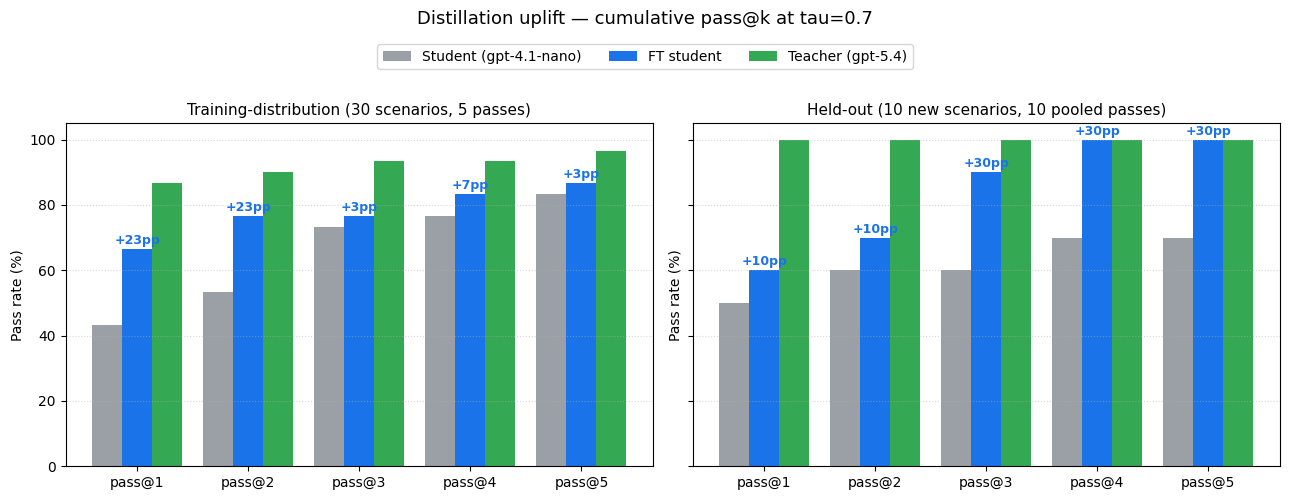

In [22]:
# Unified post-SFT eval: cumulative pass@k on training-distribution AND held-out, with uplift chart.
import os
import re
import subprocess
from collections import defaultdict
from pathlib import Path

NB_DIR = Path.cwd() if Path.cwd().name == "AgentTracesDistillation" else NB_DIR
RESULTS_DIR = NB_DIR / "results"
TAU = 0.70  # combined-score success threshold


# ----- Optional rerun hooks -------------------------------------------------
def _maybe_rerun_5pass():
    if os.environ.get("RERUN_5PASS", "0") != "1":
        return
    ft_model = os.environ.get("FT_MODEL", globals().get("FT_MODEL", ""))
    if not ft_model:
        raise RuntimeError("RERUN_5PASS=1 requires FT_MODEL to be set")
    print("RERUN_5PASS=1 -> regenerating training-distribution 5-pass files")
    for role, model in (("student", ""), ("ft", ft_model), ("teacher", "")):
        cmd = ["bash", str(NB_DIR / "scripts/run_5pass.sh"), role]
        if model:
            cmd.append(model)
        subprocess.run(cmd, cwd=NB_DIR, check=True)


def _maybe_rerun_heldout():
    if os.environ.get("RERUN_HELDOUT", "0") != "1":
        return
    ft_model = os.environ.get("FT_MODEL", globals().get("FT_MODEL", ""))
    if not ft_model:
        raise RuntimeError("RERUN_HELDOUT=1 requires FT_MODEL to be set")
    print("RERUN_HELDOUT=1 -> regenerating two independent 5-pass held-out runs")
    for run_label, target_dir in (("A", "heldout_v2_runA"), ("B", "heldout_v2_runB")):
        for role, model in (("student", ""), ("ft", ft_model), ("teacher", "")):
            cmd = ["bash", str(NB_DIR / "scripts/run_5pass_heldout.sh"), role]
            if model:
                cmd.append(model)
            print(f"  RUN {run_label} | $ {' '.join(cmd)}")
            subprocess.run(cmd, cwd=NB_DIR, check=True)
        target = RESULTS_DIR / target_dir
        target.mkdir(parents=True, exist_ok=True)
        for f in RESULTS_DIR.glob("baseline__mt__*.heldout.pass*.json"):
            (target / f.name).write_bytes(f.read_bytes())


_maybe_rerun_5pass()
_maybe_rerun_heldout()


# ----- Load per-pass solve matrices -----------------------------------------
def _load_training_passes(role: str):
    """Return list of {scenario_id: solved_bool} dicts ordered by pass number."""
    pat = re.compile(r"\.pass(\d+)\.json$")
    by_pass = {}
    for f in RESULTS_DIR.glob(f"baseline__mt__{role}__*.pass*.json"):
        if ".heldout." in f.name:
            continue
        m = pat.search(f.name)
        if m:
            by_pass[int(m.group(1))] = json.loads(f.read_text())
    out = []
    for n in sorted(by_pass):
        rows = by_pass[n].get("per_scenario", [])
        out.append({r["scenario_id"]: (r.get("combined", 0) >= TAU) for r in rows})
    return out


def _load_heldout_pooled():
    """Return list of {scenario_id: solved_bool} dicts pooled across runA + runB."""
    out = {"student": [], "ft": [], "teacher": []}
    for d in (RESULTS_DIR / "heldout_v2_runA", RESULTS_DIR / "heldout_v2_runB"):
        if not d.exists():
            continue
        for role in out:
            for f in sorted(d.glob(f"baseline__mt__{role}__*.heldout.pass*.json")):
                rows = json.loads(f.read_text())["per_scenario"]
                out[role].append({r["scenario_id"]: (r.get("combined", 0) >= TAU) for r in rows})
    return out


def _cum_pass_at_k(passes_list):
    """passes_list[i] = {sid: solved}. Returns {k: pass@k_mean} for k = 1..len(passes_list)."""
    if not passes_list:
        return {}
    ids = sorted({sid for p in passes_list for sid in p})
    out = {}
    for k in range(1, len(passes_list) + 1):
        n_solved = sum(
            1 for sid in ids if any(passes_list[i].get(sid, False) for i in range(k))
        )
        out[k] = n_solved / max(1, len(ids))
    return out


training = {role: _load_training_passes(role) for role in ("student", "ft", "teacher")}
heldout = _load_heldout_pooled()

train_passk = {role: _cum_pass_at_k(training[role]) for role in training}
held_passk = {role: _cum_pass_at_k(heldout[role]) for role in heldout}


# ----- Print headline tables ------------------------------------------------
def _print_table(title, passk, ks):
    print(f"\n=== {title} (cumulative pass@k, tau={TAU}) ===")
    print(f"  {'k':>3} | {'student':>8} | {'ft':>8} | {'teacher':>8} | {'lift(FT-S)':>11} | {'recovered':>10}")
    print("  " + "-" * 64)
    for k in ks:
        s = passk["student"].get(k, float("nan"))
        f = passk["ft"].get(k, float("nan"))
        t = passk["teacher"].get(k, float("nan"))
        lift = f - s
        rec = lift / (t - s) if (t - s) > 0 else float("nan")
        print(f"  {k:>3} | {s:>7.1%} | {f:>7.1%} | {t:>7.1%} | {lift*100:>+9.1f}pp | {rec:>9.0%}")


train_n = max((len(p) for p in training.values()), default=0)
held_n = max((len(p) for p in heldout.values()), default=0)

if train_n:
    _print_table(
        f"Training-distribution: 30 scenarios x {train_n} passes",
        train_passk, range(1, min(train_n, 5) + 1),
    )
else:
    print("No training-distribution per-pass files found in results/. Run scripts/run_5pass.sh.")

if held_n:
    _print_table(
        f"Held-out: 10 new scenarios x {held_n} pooled passes",
        held_passk, range(1, min(held_n, 5) + 1),
    )
else:
    print("No held-out per-pass files found in results/heldout_v2_run{A,B}/. Run scripts/run_5pass_heldout.sh.")


# ----- Uplift chart ---------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

KS = list(range(1, 6))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)


def _plot_panel(ax, passk, title, n_passes):
    ks = [k for k in KS if k <= n_passes]
    s = [passk["student"].get(k, np.nan) * 100 for k in ks]
    f = [passk["ft"].get(k, np.nan) * 100 for k in ks]
    t = [passk["teacher"].get(k, np.nan) * 100 for k in ks]
    x = np.arange(len(ks))
    w = 0.27
    ax.bar(x - w, s, w, label="Student (gpt-4.1-nano)", color="#9aa0a6")
    ax.bar(x,     f, w, label="FT student",             color="#1a73e8")
    ax.bar(x + w, t, w, label="Teacher (gpt-5.4)",       color="#34a853")
    for i, (sv, fv) in enumerate(zip(s, f)):
        if not np.isnan(sv) and not np.isnan(fv):
            ax.annotate(f"+{fv - sv:.0f}pp",
                        xy=(i, max(sv, fv) + 1.5),
                        ha="center", fontsize=9, color="#1a73e8", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([f"pass@{k}" for k in ks])
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 105)
    ax.set_ylabel("Pass rate (%)")
    ax.grid(axis="y", linestyle=":", alpha=0.5)


if train_n:
    _plot_panel(axes[0], train_passk, f"Training-distribution (30 scenarios, {train_n} passes)", train_n)
if held_n:
    _plot_panel(axes[1], held_passk, f"Held-out (10 new scenarios, {held_n} pooled passes)", held_n)

handles, labels = axes[0].get_legend_handles_labels() if train_n else axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.04), fontsize=10)
fig.suptitle(f"Distillation uplift — cumulative pass@k at tau={TAU}", y=1.10, fontsize=13)
plt.tight_layout()
plt.show()


## 10. Headline result, caveats, and what to look at next

### Headline (cumulative pass@k at tau=0.70 — produced by §9)

| Metric | Student `gpt-4.1-nano` | FT student | Teacher `gpt-5.4` | Lift (FT − S) | Recovered |
|---|---|---|---|---|---|
| **Training pass@1** (5 passes × 30 scenarios) | 43% | **67%** | 87% | **+23pp** | 54% |
| **Training pass@2** | 53% | **77%** | 90% | **+23pp** | 64% |
| **Training pass@5** | 83% | 87% | 97% | +3pp | 25% |
| **Held-out pass@1** (10 pooled passes × 10 new scenarios) | 50% | **60%** | 100% | **+10pp** | 20% |
| **Held-out pass@2** | 60% | **70%** | 100% | **+10pp** | 25% |
| **Held-out pass@3** | 60% | **90%** | 100% | **+30pp** | 75% |
| **Held-out pass@4** | 70% | **100%** | 100% | **+30pp** | 100% |
| **Held-out pass@5** | 70% | **100%** | 100% | **+30pp** | 100% |

### What we can claim
1. **Single-attempt accuracy improved.** Training-distribution pass@1 lifts +23pp (43% → 67%); held-out pass@1 lifts +10pp (50% → 60%). Lift direction and ordering (Teacher > FT > Student) hold on every measurement.
2. **Improvement transfers to unseen orders.** Held-out scenarios use customer and order rows the FT model never saw in training; the lift is preserved at small-k and *grows* at larger k — inconsistent with a memorisation-only explanation.
3. **Improvement is broad, not single-task.** On held-out, FT wins on 6 of 10 scenarios spanning 6 distinct task families: lost-package, cancellation, mid-conversation pivot, customer-underclaim, late-delivery extension, status-mismatch.
4. **Reliability improves dramatically.** On held-out at pass@4–5, FT solves **100%** of scenarios; the unfine-tuned student plateaus at 70%. The FT model recovers the entire teacher headroom by pass@4.

### What we cannot claim
- **The teacher is not closed at single-attempt.** Held-out pass@1 still has the teacher ~40pp ahead of FT. This is partial distillation, not parity.
- **Two scenarios regressed on held-out** (`H04` defective-refund −2 passes pooled, `H10` cross-order combo −1 pass). The first looks like variance against an already-saturated student; the second is a genuine multi-order weakness worth follow-up.

### Reproducibility checklist
- Canonical 30-scenario eval: [eval/scenarios_train.json](eval/scenarios_train.json)
- Held-out 10-scenario eval: [eval/scenarios_validation.json](eval/scenarios_validation.json)
- Extended database (5 new customers + 13 new orders): backups at `datasets/agents/Zava-Ignite-RL-Lab/data/zava_db.json.bak.heldout`
- Multi-pass drivers: [scripts/run_5pass.sh](scripts/run_5pass.sh) and [scripts/run_5pass_heldout.sh](scripts/run_5pass_heldout.sh)
- Aggregator: [scripts/pass_at_k.py](scripts/pass_at_k.py)
- Raw eval files: `results/baseline__mt__{role}__*.pass{1-5}.json` and `results/heldout_v2_run{A,B}/`


### Cleanup

Close the project client + credential. The downloaded SFT files in `results/sft_data/` and the cached eval JSON in `results/` are kept on disk for future re-runs.

In [ ]:
# Optional: delete the data-generation job. This does NOT delete the produced files.
# project_client.beta.datasets.delete_generation_job(job_id=job.id)
# print(f"Deleted generation job {job.id}")

project_client.close()
credential.close()
print("Project client + credential closed.")